# Testing notebook

This Notebook can be used as a demo of the package and some of the main functions in it.


Johan Rosgaard, 04/12/2026

### Load imports

In [1]:
# Main module
%reset -f

# autoreload imports
%load_ext autoreload
%autoreload 2

from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'lightgray'
plt.rcParams['axes.facecolor'] = 'white'


from neurons_model.simulation.config import NetworkConfig
from neurons_model.simulation.network import Network
from neurons_model.simulation.simulation import run_simulation
from neurons_model.simulation.scaling import scale_network_config

from neurons_model.readouts.sim_metrics import compute_metrics
from neurons_model.readouts.plot_metrics import plot_spike_raster
from neurons_model.readouts.pop_plot import plot_weight_heatmap, plot_connectivity_heatmap, plot_population_weight_summary
from neurons_model.readouts.sweep_plot import sweep_plot_general, sweep_plot_norm_summary
from neurons_model.readouts.calvo_analysis import calvo_pca, calvo_pca_plot

from neurons_model.functionals import functional_J


PYTHON: /opt/anaconda3/envs/neuronSB1/bin/python
FILE: /Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/loader.py
CWD: /Users/johanrosgaard/Documents/BNQ/neurons_model/tests
YAML OK: 6.0.3


In [2]:

# --- Set diagnostic mode --- Change to True to enable extended diagnostic/verification output and characterization
diagnostic_mode = False

if diagnostic_mode:
    print("Running in diagnostic mode: Print extended output and characterization.")

# --- Set extended output metrics mode --- Change to True to enable extended output and characterization
extnd_mode = True

if extnd_mode:
    print("Running in extended output mode: Compute and print additional metrics.")


Running in extended output mode: Compute and print additional metrics.


## Load presets and network

In [3]:
# Load path and yaml config
project_root = Path.cwd().parent
config_paths = [
    project_root / "src" / "neurons_model" / "presets" / "healthy_quiet.yaml",      # 0
    project_root / "src" / "neurons_model" / "presets" / "healthy_active_1.yaml",   # 1
    project_root / "src" / "neurons_model" / "presets" / "healthy_active_2.yaml",   # 2
]

for config_path_i in config_paths:
    print(config_path_i)
    if diagnostic_mode:
        print(config_path_i.exists())


# ----- Load and scale network config -----
config_path = config_paths[1]

with open(config_path, "r", encoding="utf-8") as f:
    raw = yaml.safe_load(f)

cfg = NetworkConfig.model_validate(raw)
scaled_cfg = scale_network_config(cfg, scale_factor=1.0, strategy="preserve_in_degree")

# --- Diagnostic output ---
if diagnostic_mode:
    print("Loaded:", cfg.name)
    print("Populations:", [p.name for p in cfg.populations])
    print("Pathways:", len(cfg.pathways))
    print("Original total neurons:", sum(p.count_n for p in cfg.populations))
    print("Scaled total neurons:", sum(p.count_n for p in scaled_cfg.populations))


# Create original and scaled networks
base_net = Network.from_config(cfg)
scaled_net = Network.from_config(scaled_cfg)

# set net
net = scaled_net

print("Base weights shape:", base_net.weights.shape, (base_net.weights != 0).sum())
print("Scaled weights shape:", scaled_net.weights.shape, (scaled_net.weights != 0).sum())

if diagnostic_mode:
    print("Base n neurons:", base_net.v_mv.shape[0])
    print("Scaled n neurons:", scaled_net.v_mv.shape[0])

    print("Base nonzero synapses:", (base_net.weights != 0).sum())
    print("Scaled nonzero synapses:", (scaled_net.weights != 0).sum())

    print("Base nonzero receptor codes:", (base_net.receptor_code != 0).sum())
    print("Scaled nonzero receptor codes:", (scaled_net.receptor_code != 0).sum())

    print(
        "Base same count:",
        ((base_net.weights != 0).sum() == (base_net.receptor_code != 0).sum())
    )
    print(
        "Scaled same count:",
        ((scaled_net.weights != 0).sum() == (scaled_net.receptor_code != 0).sum())
    )

/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_quiet.yaml
/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_active_1.yaml
/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_active_2.yaml
Base weights shape: (100, 100) 1625
Scaled weights shape: (100, 100) 1625


### Check synapses and receptors

In [4]:
# Check for recurrent synapses
for pop in net.populations:
    ix = np.ix_(pop.indices, pop.indices)
    n_rec = (net.weights[ix] != 0).sum()

    print(pop.name, "recurrent synapses:", n_rec)

CODE_TO_RECEPTOR = {1: "ampa", 2: "nmda", 3: "gaba_a", 4: "gaba_b"}

# Check receptor codes and counts
codes, counts = np.unique(net.receptor_code[net.receptor_code != 0], return_counts=True)

if extnd_mode:
    print({CODE_TO_RECEPTOR[int(c)]: int(n) for c, n in zip(codes, counts)})


mask_w = net.weights != 0

# --- Diagnostic output ---
if diagnostic_mode:
    print("\ndelay aligned:", np.all(net.delays_ms[mask_w] != 0))
    print("tau_rise aligned:", np.all(net.tau_rise_ms[mask_w] != 0))
    print("tau_decay aligned:", np.all(net.tau_decay_ms[mask_w] != 0))
    print("reversal finite on synapses:", np.all(np.isfinite(net.reversal_mv[mask_w])))

Ex recurrent synapses: 1034
In_fast recurrent synapses: 30
In_adapt recurrent synapses: 14
{'ampa': 1383, 'gaba_a': 242}


### Configure simulation

For reference, available rhythm bands are:

- `infraslow`: `BandSpec(0.01, 0.1, 0.3)`
- `delta`: `BandSpec(0.5, 4.0, 0.7)`
- `theta`: `BandSpec(4.0, 8.0, 0.8)`
- `alpha`: `BandSpec(8.0, 13.0, 1.0)`
- `sigma`: `BandSpec(12.0, 16.0, 0.7)`
- `beta`: `BandSpec(13.0, 30.0, 0.6)`
- `gamma`: `BandSpec(30.0, 80.0, 0.4)`

In [5]:
# Run simulation for chosen rhythm and integrator
# In this example, we use the "rk4" integrator and "gamma" rhythm, but these can be changed as needed.
sim_result = run_simulation(net, integrator="rk4", rhythm="gamma", full_result=True)


Running simulation with integrator='rk4', rhythm='gamma', dt=0.01 ms, duration=400.0 ms
Drive parameters: 

Rhythm: gamma
Amplitude (dimensionless, normalized): 0.442
Frequency estimate (Hz): 78.40
Phase jitter (radians): 0.1
Amplitude noise std fraction: 0.1

****** Starting simulation... ******

Total sim. run time:  2.3185861110687256 seconds

****** Simulation completed. ******



In [6]:
#diagnostic_mode = False

# --- Diagnostic output ---
if diagnostic_mode:
    print(sim_result.__dict__.keys())
    print()
    print(sim_result)
    print()
    print(type(sim_result.v_trace))
    print(np.shape(sim_result.v_trace))
    print(sim_result.v_trace.ndim)


# ---- Per neuron voltage traces ----
v_df = pd.DataFrame(sim_result.v_trace.T)
v_df.columns = [f"v_neuron_{i}" for i in range(v_df.shape[1])]

per_neuron_sim_results_df = pd.concat(
    [pd.DataFrame({"t_ms": sim_result.t_ms, "field_proxy": sim_result.field_proxy}), v_df],
    axis=1,
)


# --- Example: Change extnd_mode to True to print first 5 neurons
if extnd_mode:
    print(per_neuron_sim_results_df.head())

   t_ms  field_proxy  v_neuron_0  v_neuron_1  v_neuron_2  v_neuron_3  \
0  0.00          0.0  -64.993170  -64.992216  -64.992026  -64.992234   
1  0.01          0.0  -64.985601  -64.985292  -64.985431  -64.985581   
2  0.02          0.0  -64.978254  -64.978363  -64.977662  -64.977912   
3  0.03          0.0  -64.970955  -64.970872  -64.969933  -64.970962   
4  0.04          0.0  -64.963159  -64.964170  -64.962347  -64.964358   

   v_neuron_4  v_neuron_5  v_neuron_6  v_neuron_7  ...  v_neuron_90  \
0  -64.991877  -64.992600  -64.993313  -64.992630  ...   -63.996012   
1  -64.984255  -64.984582  -64.985323  -64.985029  ...   -63.992299   
2  -64.977046  -64.976511  -64.978401  -64.977085  ...   -63.988819   
3  -64.969113  -64.969498  -64.971957  -64.970296  ...   -63.985223   
4  -64.961259  -64.961231  -64.964550  -64.963257  ...   -63.981983   

   v_neuron_91  v_neuron_92  v_neuron_93  v_neuron_94  v_neuron_95  \
0   -63.996750   -63.996966   -63.995931   -63.996721   -63.996594   


In [7]:
sim_metric_results = compute_metrics(sim_result, save=False)

# --- Print metrics: Change extnd_mode to True to enable printing
extnd_mode = True
if extnd_mode:
    print("Computed metrics:")
    for k, v in sim_metric_results.items():
        for v in [v] if np.isscalar(v) else v:
            print(f"{k}: {v}")

extnd_mode = False

Computed metrics:
v_finite: True
field_finite: True
mean_membrane_potential_mv: -70.61205131056377
min_membrane_potential_mv: -176.88122112079247
max_membrane_potential_mv: -48.40321195645112
field_proxy_mean: 24.326968779211786
field_proxy_std: 123.6506768326798
field_proxy_max: 971.9238099049397
Ex_spike_count: 170
Ex_mean_firing_rate_hz: 5.666808336875088
Ex_synchrony_index: 0.01683520372035887
In_fast_spike_count: 0
In_fast_mean_firing_rate_hz: 0.0
In_fast_synchrony_index: nan
In_adapt_spike_count: 7
In_adapt_mean_firing_rate_hz: 1.4583697925781478
In_adapt_synchrony_index: -2.500062501562526e-05
total_spike_count: 177
n_populations: 3
population_count_entropy_bits: 0.03342488487301076
overall_shannon_entropy: 0.0007038682066963491


## Create heatmaps for weights, connectivity and population weights

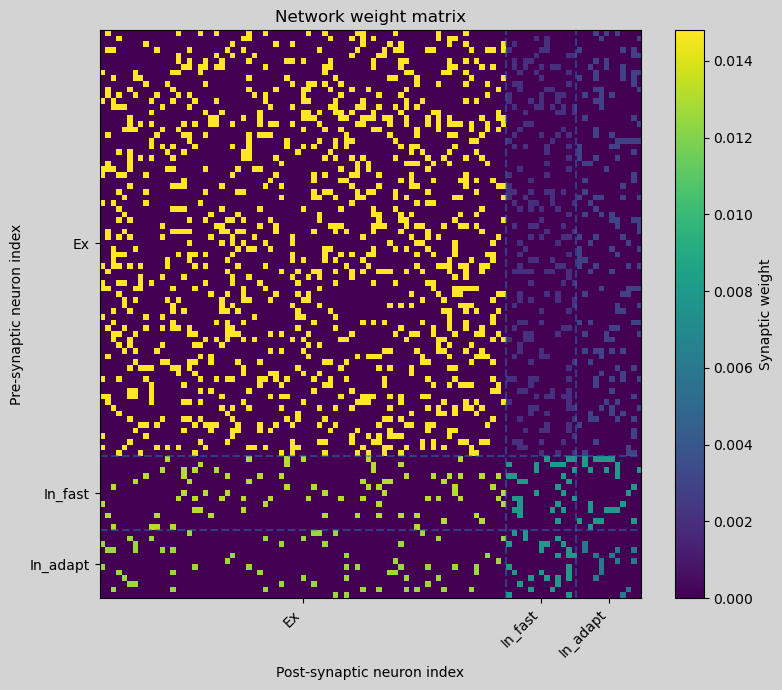

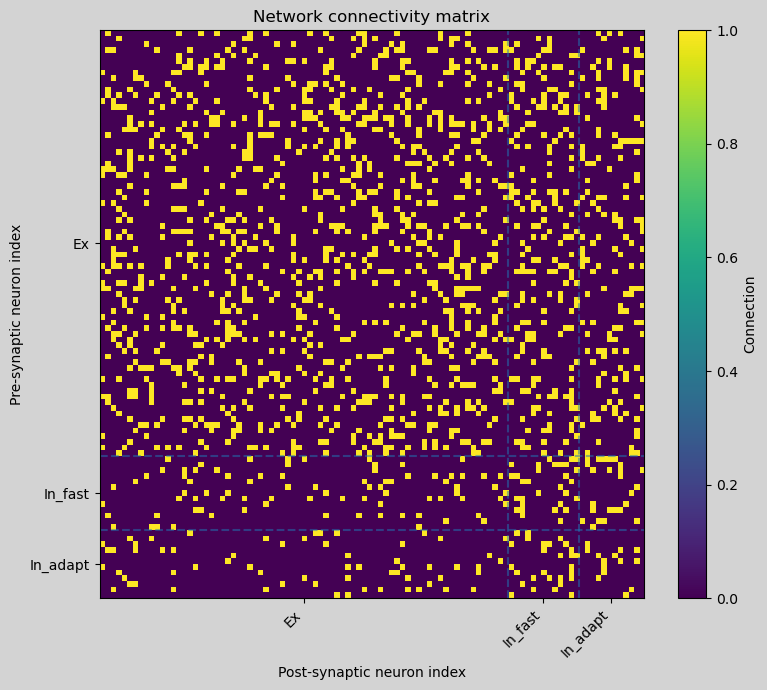

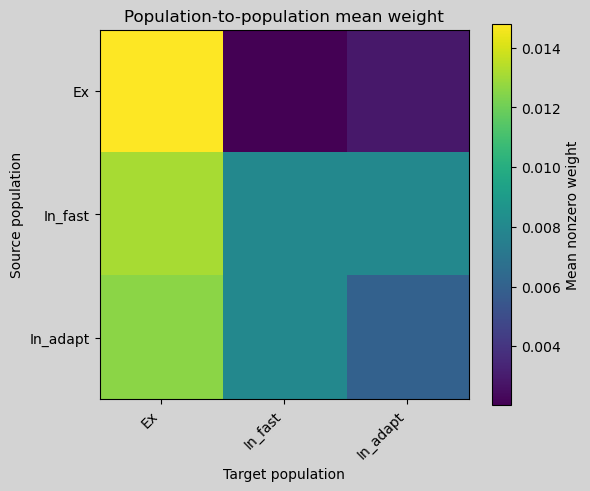

In [8]:
# Plots individual synaptic weights
plot_weight_heatmap(net)

# Plots individual synaptic connectivity
plot_connectivity_heatmap(net)

# Plots summary of population-level weights
plot_population_weight_summary(net)

total spikes: 177
Ex spikes: 170
In_fast spikes: 0
In_adapt spikes: 7
-285.1530840668567


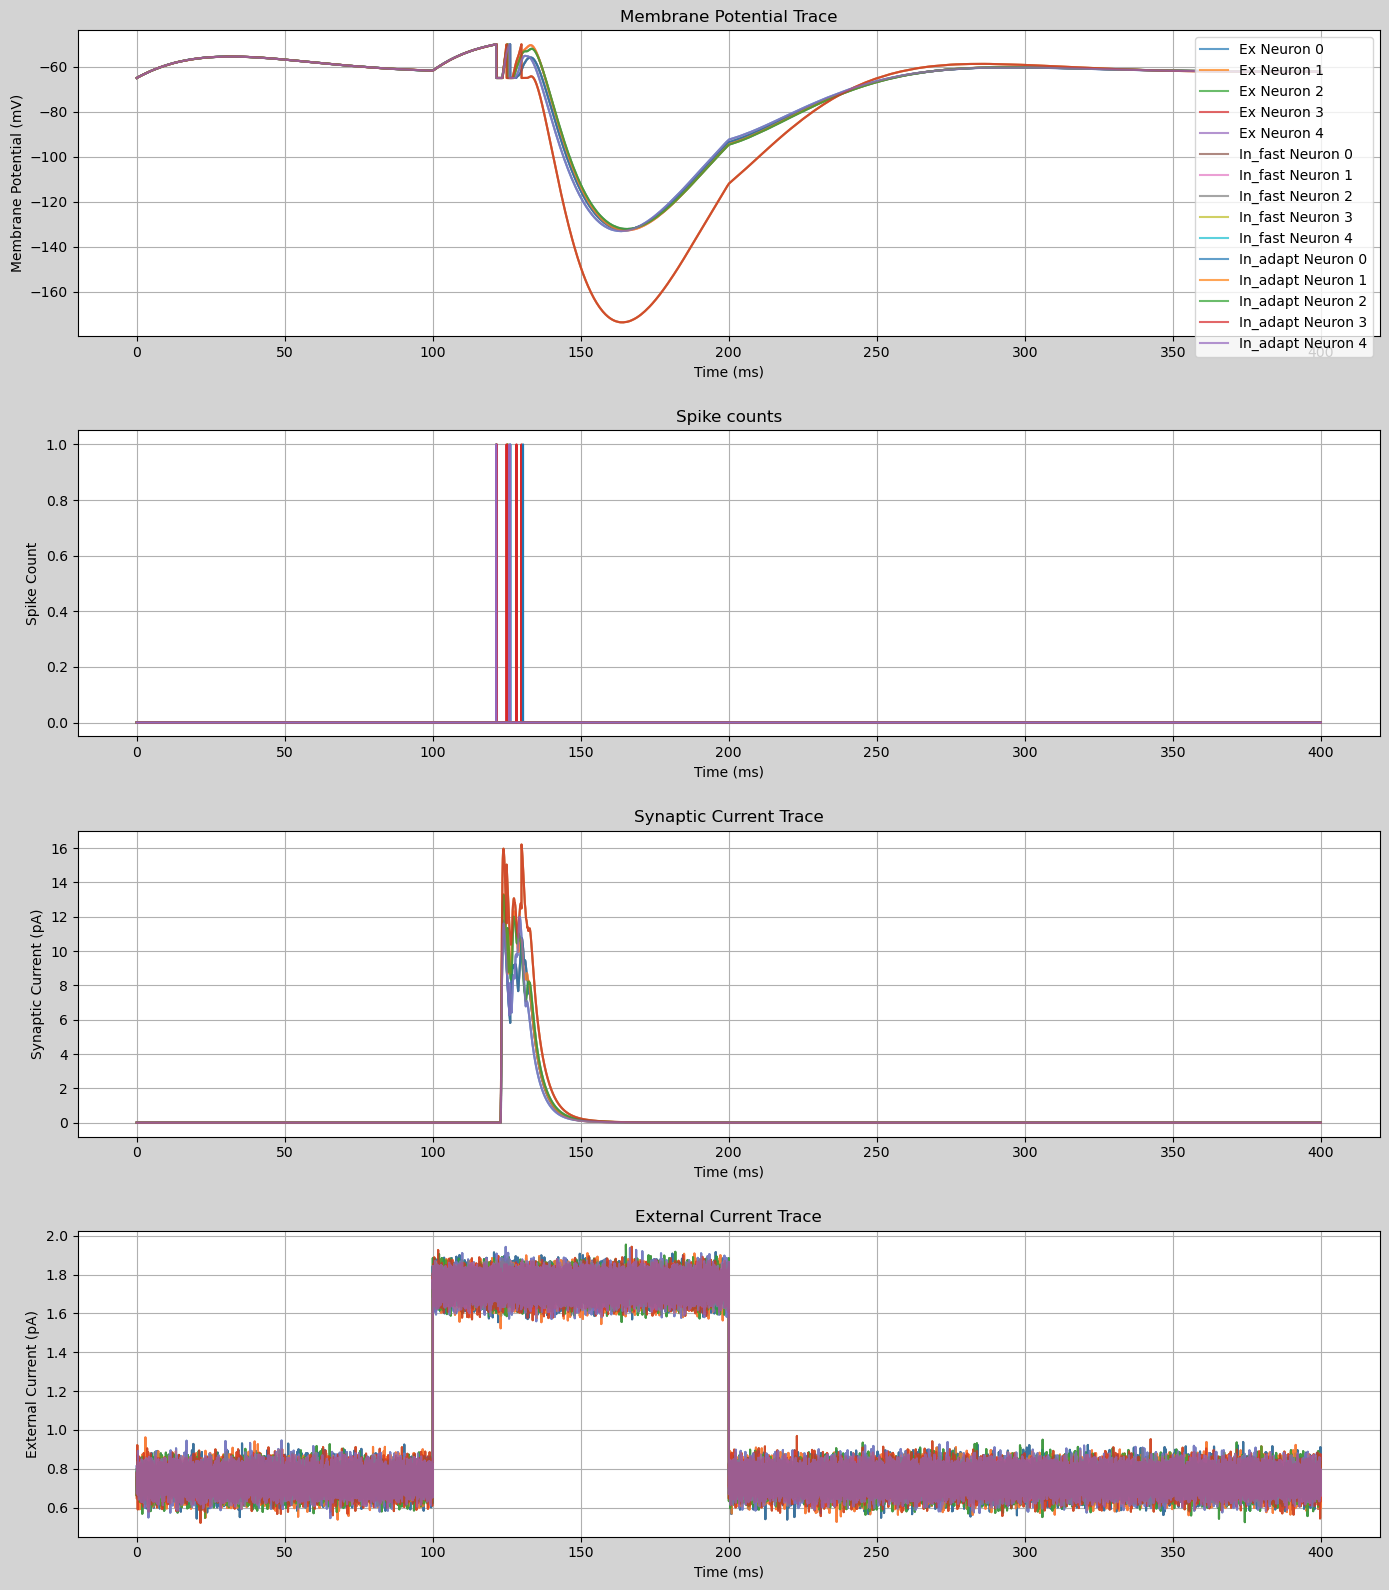

In [9]:
# Print Spike summary
print("total spikes:", sum(arr.sum() for arr in sim_result.spike_counts.values()))
for name, arr in sim_result.spike_counts.items():
    print(name, "spikes:", int(arr.sum()))

# Compute and print functional J
print(functional_J(sim_metric_results))


if diagnostic_mode:
    print("v finite:", np.all(np.isfinite(sim_result.v_trace)))
    print("field finite:", np.all(np.isfinite(sim_result.field_proxy)))


# Plotting 'TRUE', to disable, change to False
plotting = True
if plotting:
    # Plot spike raster for first 5 neurons
    plot_spike_raster(sim_result, num_neurons=5)


## Simulation using the healthy active preset.

In [10]:
# Healthy active 1 config path
for config_path_i in config_paths:
    print(config_path_i)
    if diagnostic_mode:
        print(config_path_i.exists())


# ----- Load and scale network config -----
config_path = config_paths[1]

with open(config_path, "r", encoding="utf-8") as f:
    raw = yaml.safe_load(f)

cfg = NetworkConfig.model_validate(raw)
scaled_cfg = scale_network_config(cfg, scale_factor=1.0, strategy="preserve_in_degree")

# Create original and scaled networks
base_net = Network.from_config(cfg)
scaled_net = Network.from_config(scaled_cfg)

# set net
net = scaled_net

# Print weight shapes and nonzero counts for both base and scaled networks
print("Base weights shape:", base_net.weights.shape, (base_net.weights != 0).sum())
print("Scaled weights shape:", scaled_net.weights.shape, (scaled_net.weights != 0).sum())


# Run simulation for chosen rhythm and integrator
# In this example, we use the "rk4" integrator and "gamma" rhythm, but these can be changed as needed.
sim_result_2 = run_simulation(net, integrator="rk4", rhythm="gamma", full_result=True)

/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_quiet.yaml
/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_active_1.yaml
/Users/johanrosgaard/Documents/BNQ/neurons_model/src/neurons_model/presets/healthy_active_2.yaml
Base weights shape: (100, 100) 1625
Scaled weights shape: (100, 100) 1625
Running simulation with integrator='rk4', rhythm='gamma', dt=0.01 ms, duration=400.0 ms
Drive parameters: 

Rhythm: gamma
Amplitude (dimensionless, normalized): 0.442
Frequency estimate (Hz): 78.40
Phase jitter (radians): 0.1
Amplitude noise std fraction: 0.1

****** Starting simulation... ******

Total sim. run time:  2.408614158630371 seconds

****** Simulation completed. ******



In [11]:
# ---- Per neuron voltage traces ----
v_df = pd.DataFrame(sim_result_2.v_trace.T)
v_df.columns = [f"v_neuron_{i}" for i in range(v_df.shape[1])]

per_neuron_sim_results_df = pd.concat(
    [pd.DataFrame({"t_ms": sim_result_2.t_ms, 
                   "field_proxy": sim_result_2.field_proxy
                   }), v_df], axis=1,)

# Compute simulation metrics
sim_metric_results = compute_metrics(sim_result_2, save=False)


In [12]:
# Normal version of PCA

projected_df, eigenvalues, eigenvectors, explained_variance_ratio = calvo_pca(
    v_df,
    n_components=10,)

print(projected_df.head())
print("Top 10 eigenvalues:", eigenvalues[:10])
print("Top 10 explained variance ratios:", explained_variance_ratio[:10])

# ------------------------------------------------------------------------------------
# Z-score standardized version of PCA

v_df_z = (v_df - v_df.mean()) / v_df.std(ddof=0)
v_df_z = v_df_z.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

projected_df_z, eigenvalues, eigenvectors, explained_variance_ratio = calvo_pca(
    v_df_z,
    n_components=10,)

print(projected_df_z.head())
print("Top 10 eigenvalues:", eigenvalues[:10])
print("Top 10 explained variance ratios:", explained_variance_ratio[:10])

         PC1        PC2        PC3        PC4        PC5       PC6       PC7  \
0  76.780283  30.851954 -15.285223  12.324955 -11.460316  5.783946  1.654460   
1  76.843875  30.852644 -15.273788  12.310812 -11.449768  5.779551  1.652748   
2  76.906725  30.853425 -15.263109  12.296430 -11.439973  5.774671  1.651308   
3  76.969336  30.853965 -15.251533  12.282741 -11.430184  5.770321  1.649831   
4  77.032056  30.854811 -15.240522  12.268494 -11.420879  5.766260  1.648645   

        PC8       PC9      PC10  
0  1.527987 -0.127406  1.835499  
1  1.527508 -0.125519  1.834197  
2  1.526862 -0.125190  1.832838  
3  1.525839 -0.125496  1.831310  
4  1.524758 -0.124469  1.830069  
Top 10 eigenvalues: [4.90907132e+04 1.14401272e+03 1.08926502e+02 3.64843703e+01
 1.73222517e+01 9.29797315e+00 3.60802867e+00 2.45655133e+00
 1.41799268e+00 1.06829072e+00]
Top 10 explained variance ratios: [9.73567351e-01 2.26880679e-02 2.16023111e-03 7.23558274e-04
 3.43535010e-04 1.84397465e-04 7.15544486e-05 

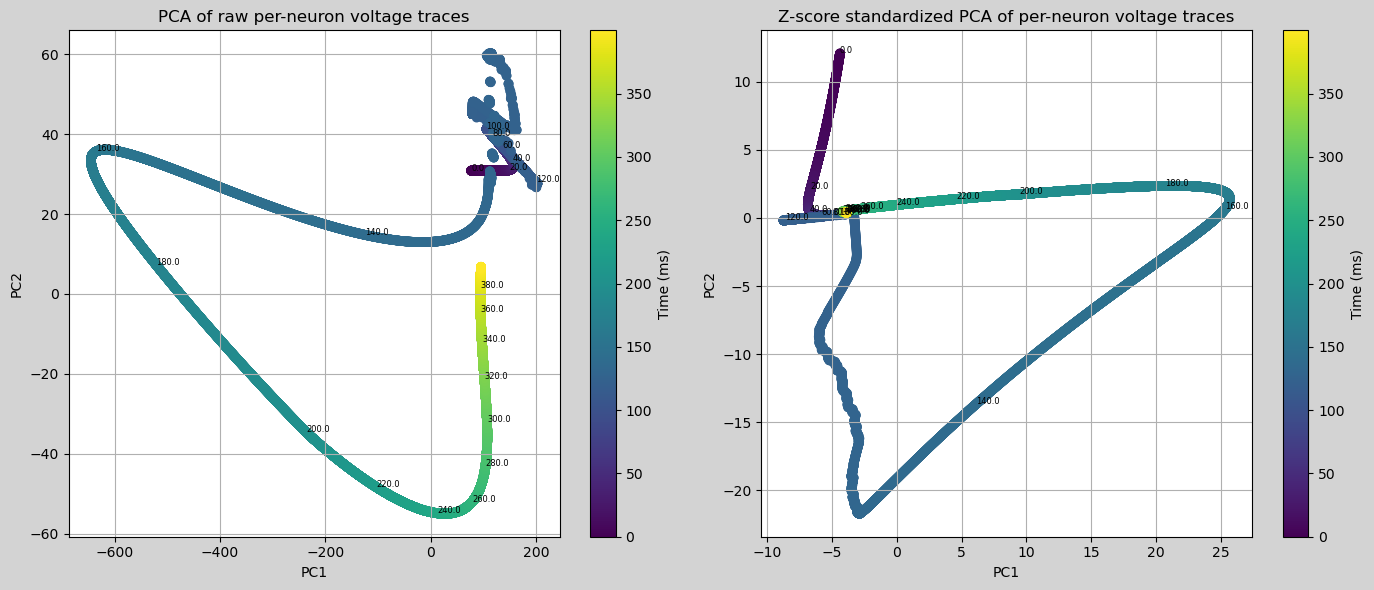

In [13]:
# Add time for coloring
projected_df["t_ms"] = sim_result.t_ms
projected_df_z["t_ms"] = sim_result.t_ms

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

# Normal version of PCA

sc = plt.scatter(
    projected_df["PC1"],
    projected_df["PC2"],
    c=projected_df["t_ms"],
    cmap="viridis",
)

for idx in range(0, len(projected_df), max(1, len(projected_df) // 20)):
    row = projected_df.iloc[idx]
    plt.annotate(f"{row['t_ms']:.1f}", (row["PC1"], row["PC2"]), fontsize=6)

plt.colorbar(sc, label="Time (ms)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of raw per-neuron voltage traces")
plt.grid()

plt.subplot(1, 2, 2)

# z-score standardized version of PCA

sc = plt.scatter(
    projected_df_z["PC1"],
    projected_df_z["PC2"],
    c=projected_df_z["t_ms"],
    cmap="viridis",
)

# Optional annotations: label a few points instead of every point
for idx in range(0, len(projected_df_z), max(1, len(projected_df_z) // 20)):
    row = projected_df_z.iloc[idx]
    plt.annotate(f"{row['t_ms']:.1f}", (row["PC1"], row["PC2"]), fontsize=6)

plt.colorbar(sc, label="Time (ms)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Z-score standardized PCA of per-neuron voltage traces")
plt.grid()


plt.tight_layout()
plt.show()

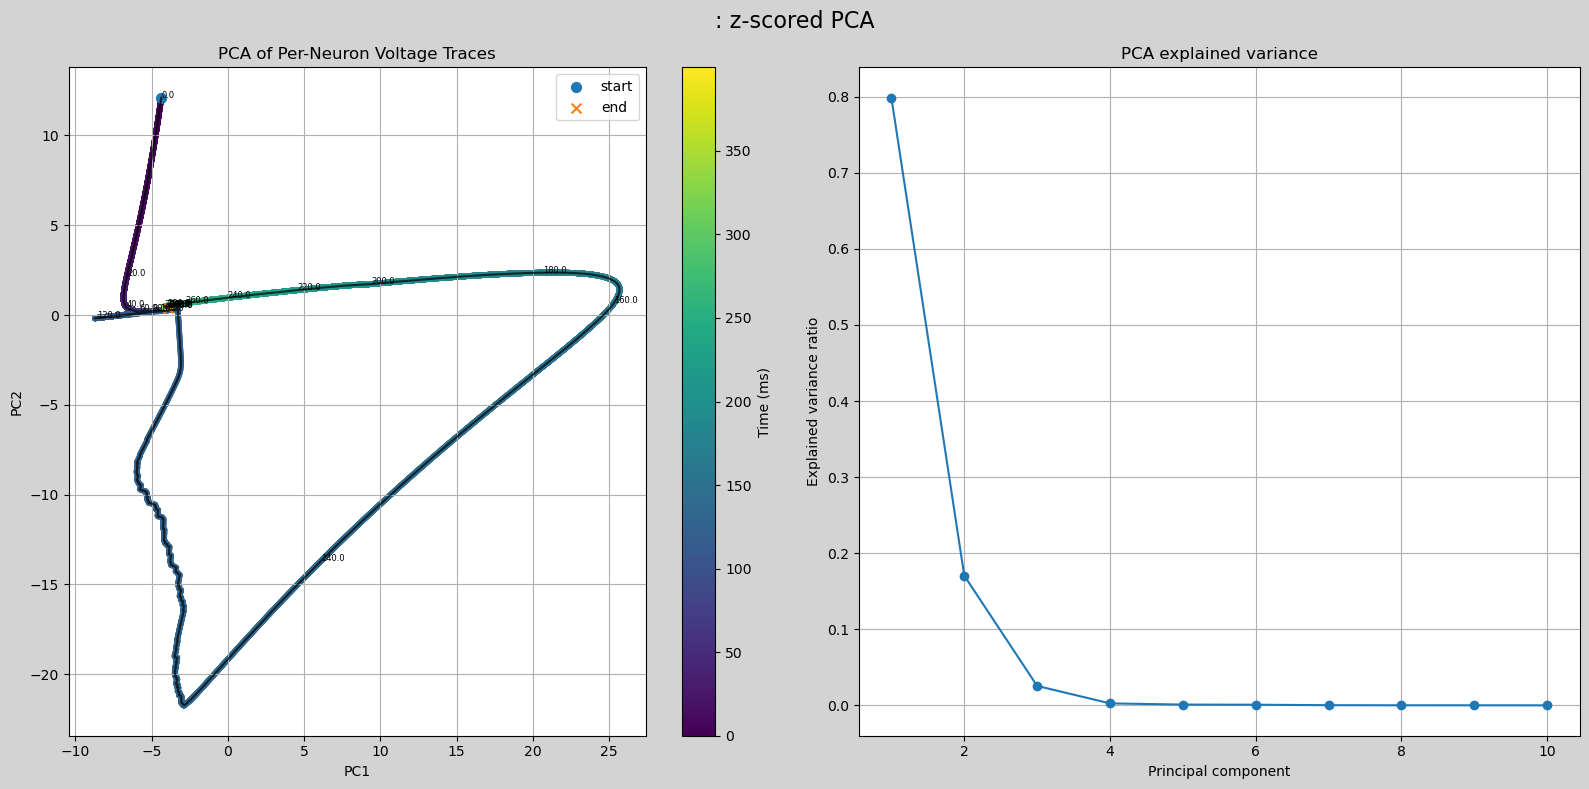

(<Figure size 1600x800 with 3 Axes>,
             PC1        PC2       PC3       PC4       PC5       PC6       PC7  \
 0     -4.361789  12.100577 -2.435450  1.060098 -1.450582  1.082672 -0.159072   
 1     -4.363558  12.089415 -2.434633  1.060482 -1.449429  1.081420 -0.158934   
 2     -4.365361  12.078728 -2.433876  1.061129 -1.448512  1.080214 -0.158919   
 3     -4.367127  12.067989 -2.433090  1.061495 -1.447523  1.079030 -0.158829   
 4     -4.368948  12.057686 -2.432353  1.061748 -1.446634  1.077845 -0.158813   
 ...         ...        ...       ...       ...       ...       ...       ...   
 39995 -3.892167   0.395815 -0.330966 -0.199781  0.183763  0.110038  0.025417   
 39996 -3.892191   0.395750 -0.331089 -0.199715  0.183877  0.109993  0.025611   
 39997 -3.892228   0.396149 -0.331213 -0.200038  0.183983  0.110049  0.025625   
 39998 -3.892286   0.396127 -0.331303 -0.200217  0.184169  0.109962  0.025758   
 39999 -3.892333   0.396066 -0.331472 -0.199934  0.183675  0.110151  0.0

In [14]:
calvo_pca_plot(sim_result_2, n_components=50, z_score_norm=True)

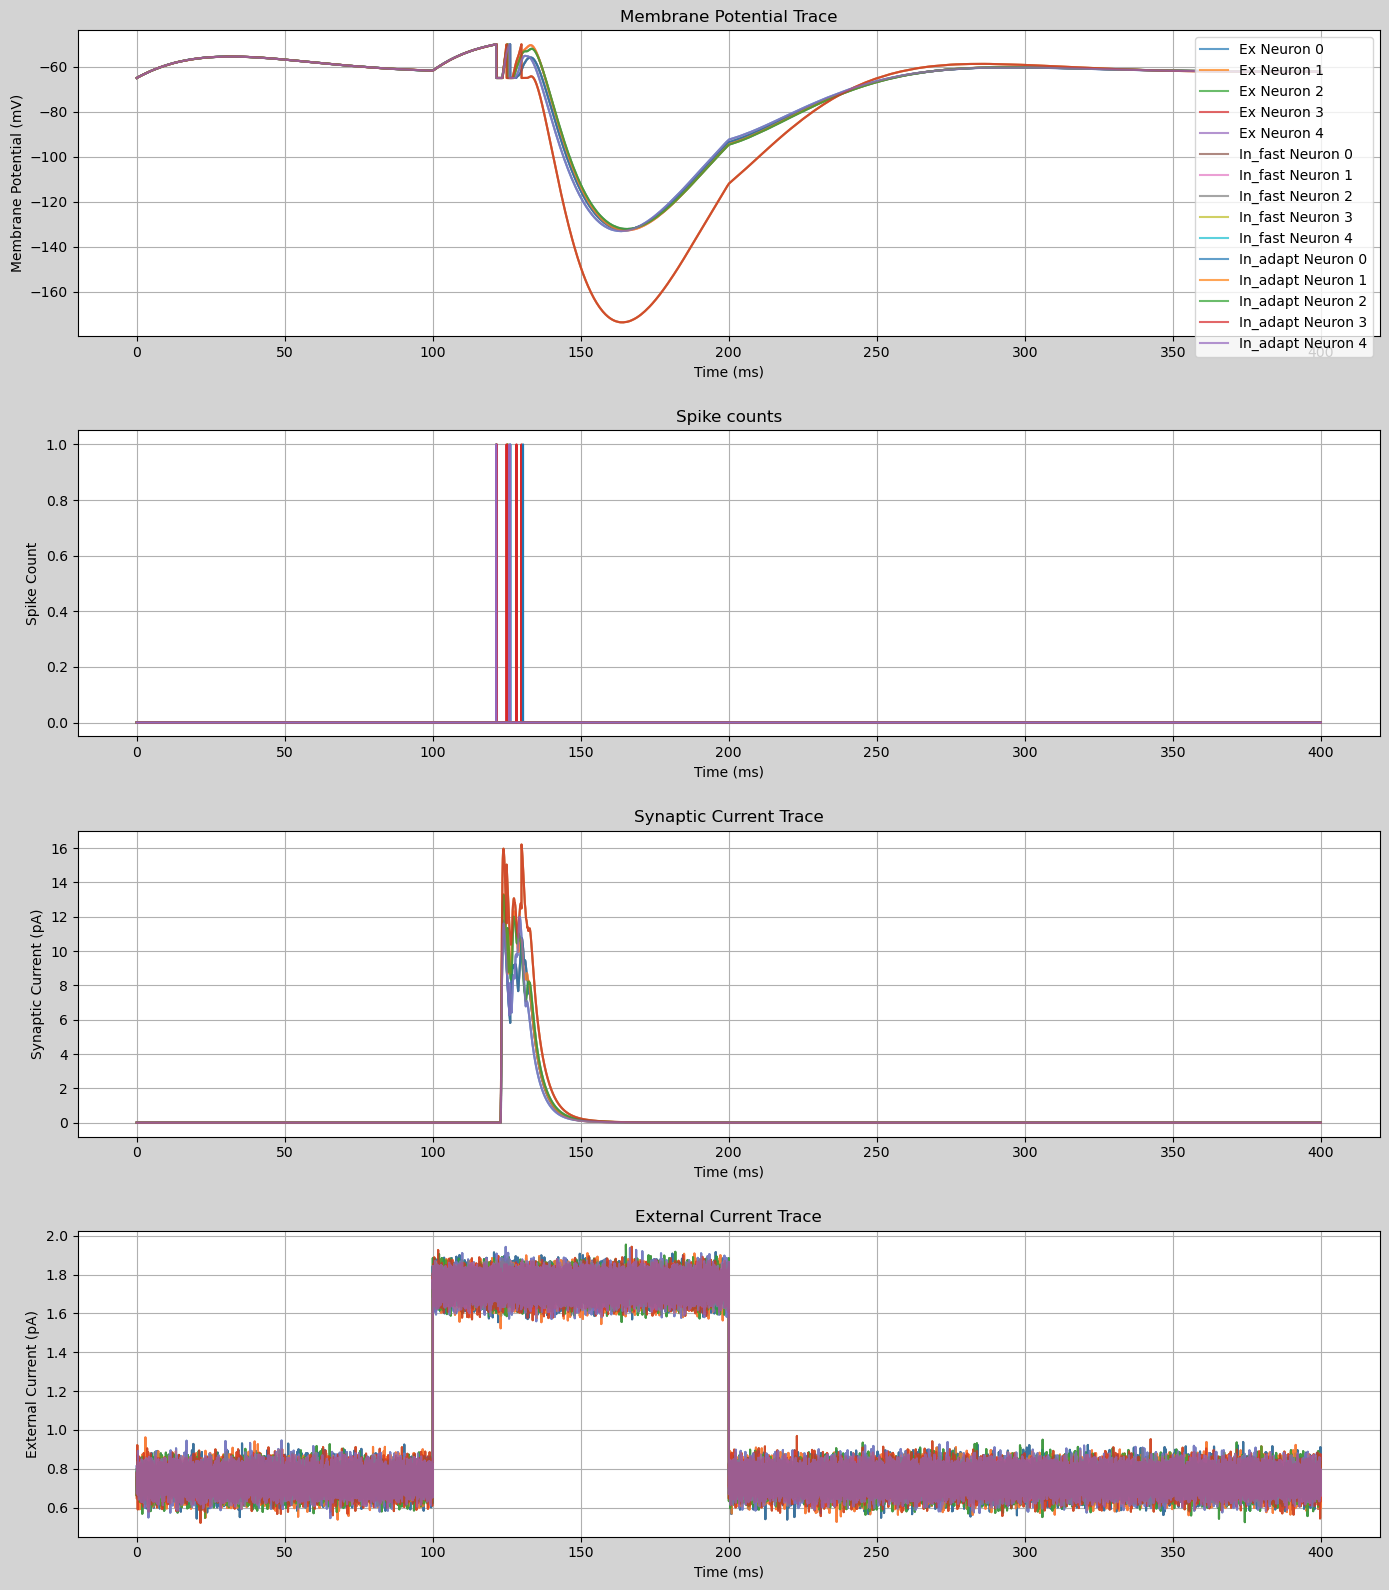

In [17]:

plot_spike_raster(sim_result, num_neurons=5)

